In [1]:
import json

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pdal
from scipy.spatial import cKDTree, Delaunay
from shapely.geometry import Point

from src.functions import estimer_z_toit, triangle_max_edge_length

In [2]:
laz_path = "../data/tuile_1.laz"
gdf = gpd.read_file("../outputs/buildings_emprises_2.geojson")
gdf = gdf.to_crs("EPSG:2154")

building_id = 933

footprint = gdf.iloc[building_id].geometry
crop_wkt = footprint.buffer(1.0).wkt

pipeline_dict = [
    laz_path,
    {
        "type": "filters.crop",
        "polygon": crop_wkt
    },
    {
        "type": "filters.outlier",
        "method": "statistical",
        "mean_k": 12,
        "multiplier": 2.0
    },
    {
        "type": "filters.expression",
        "expression": "Classification !=7"
    }
]

pipeline = pdal.Pipeline(json.dumps(pipeline_dict))
pipeline.execute()
arr = pipeline.arrays[0]

print("Points nettoyés : ", len(arr))
print(arr.dtype.names)

Points nettoyés :  3801
('X', 'Y', 'Z', 'Intensity', 'ReturnNumber', 'NumberOfReturns', 'ScanDirectionFlag', 'EdgeOfFlightLine', 'Classification', 'Synthetic', 'KeyPoint', 'Withheld', 'Overlap', 'ScanAngleRank', 'UserData', 'PointSourceId', 'GpsTime', 'ScanChannel')


In [3]:
pipeline_ground = [
    laz_path,
    {
        "type": "filters.crop",
        "polygon": footprint.buffer(6.0).wkt
    },
    {
        "type": "filters.outlier",
        "method": "statistical",
        "mean_k": 12,
        "multiplier": 2.0
    },
    {
        "type": "filters.smrf",
        "returns": "last,only",
        "where": "Classification != 7",
        "slope": 0.2,
        "threshold": 0.45,
        "window": 16.0,
        "cell": 1.0
    }
]

pipe_ground = pdal.Pipeline(json.dumps(pipeline_ground))
pipe_ground.execute()
arr_ground = pipe_ground.arrays[0]

Xg = arr_ground["X"]
Yg = arr_ground["Y"]
Zg = arr_ground["Z"]
Cg = arr_ground["Classification"]

ground_mask = Cg == 2
print("Points sol :", np.sum(ground_mask))

z_ground = float(np.median(Zg[ground_mask]))
print("z_ground =", z_ground)

Points sol : 4317
z_ground = 96.3


In [4]:
X = arr["X"]
Y = arr["Y"]
Z = arr["Z"]
C = arr["Classification"]

building_mask = C == 6

xb = X[building_mask]
yb = Y[building_mask]
zb = Z[building_mask]

z_norm = zb - z_ground

roof_mask = z_norm > 2

xr = xb[roof_mask]
yr = yb[roof_mask]
zr = zb[roof_mask]
zr_norm = z_norm[roof_mask]

print("Points de toit conservés :", len(xr))

Points de toit conservés : 2574


In [5]:
xyz_roof = np.column_stack([xr, yr, zr])
xy_roof = xyz_roof[:, :2]

xy_footprint = np.array(footprint.exterior.coords[:-1])
xy_roof = np.vstack([xy_roof, xy_footprint])

tri = Delaunay(xy_roof)
triangles = tri.simplices
print("Triangles bruts :", len(triangles))


Triangles bruts : 411


In [6]:
roof_triangles_idx = []

for simplex in triangles:
    pts2d = xy_roof[simplex]
    centroid = pts2d.mean(axis=0)

    if not footprint.contains(Point(centroid[0], centroid[1])):
        continue

    if triangle_max_edge_length(pts2d) > 5:
        continue

    roof_triangles_idx.append(simplex)

print("Triangles conservés :", len(roof_triangles_idx))


Triangles conservés : 382


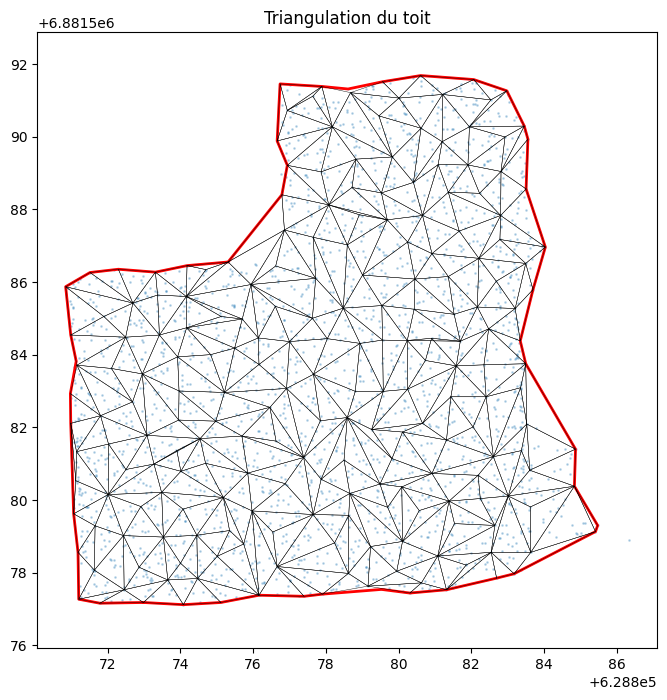

In [7]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(xb, yb, s=1, alpha=0.25)

x_fp, y_fp = footprint.exterior.xy
ax.plot(x_fp, y_fp, color="red", linewidth=2)

for simplex in roof_triangles_idx:
    pts = xy_roof[simplex]
    pts_closed = np.vstack([pts, pts[0]])
    ax.plot(pts_closed[:, 0], pts_closed[:, 1], color="black", linewidth=0.3)

ax.set_title("Triangulation du toit")
ax.axis("equal")
plt.show()

In [8]:
footprint_coords = np.array(footprint.exterior.coords[:-1])
ground_ring = np.column_stack([
    footprint_coords[:, 0],
    footprint_coords[:, 1],
    np.full(len(footprint_coords), z_ground)
])

In [9]:
top_ring = []
roof_tree = cKDTree(np.column_stack([xr, yr]))

for xy in footprint_coords:
    z_top = estimer_z_toit(xy, roof_tree, zr)
    top_ring.append([xy[0], xy[1], z_top])

top_ring = np.array(top_ring)
xyz_roof = np.vstack([xyz_roof, top_ring])

print("Nombre de sommets hauts : ", len(top_ring))

Nombre de sommets hauts :  46


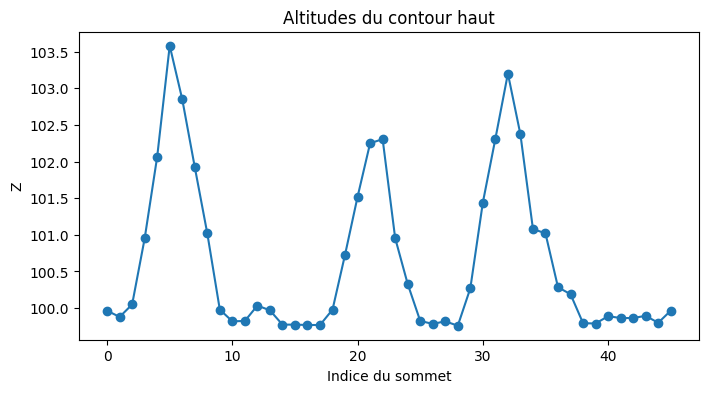

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(top_ring[:, 2], marker="o")
plt.title("Altitudes du contour haut")
plt.xlabel("Indice du sommet")
plt.ylabel("Z")
plt.show()

In [11]:
vertices = []
vertex_map = {}


def add_vertex(v, precision=3):
    key = tuple(np.round(v, precision))
    if key not in vertex_map:
        vertex_map[key] = len(vertices)
        vertices.append(list(map(float, v)))
    return vertex_map[key]

In [12]:
ground_surface = [add_vertex(v) for v in ground_ring]

In [13]:
wall_surfaces = []

n = len(footprint_coords)
for i in range(n):
    j = (i + 1) % n

    g1 = add_vertex(ground_ring[i])
    g2 = add_vertex(ground_ring[j])
    t2 = add_vertex(top_ring[j])
    t1 = add_vertex(top_ring[i])

    wall_surfaces.append([g1, g2, t2, t1])

print("Nombre de murs :", len(wall_surfaces))

Nombre de murs : 46


In [14]:
roof_surfaces = []

for simplex in roof_triangles_idx:
    surface = []
    for idx in simplex:
        v = xyz_roof[idx]
        surface.append(add_vertex(v))
    roof_surfaces.append(surface)

In [15]:
boundaries = []
semantic_surfaces = []
semantic_values = []

# RoofSurface
for surf in roof_surfaces:
    boundaries.append([surf])
    semantic_surfaces.append({"type": "RoofSurface"})
    semantic_values.append(len(semantic_surfaces) - 1)

# WallSurface
for surf in wall_surfaces:
    boundaries.append([surf])
    semantic_surfaces.append({"type": "WallSurface"})
    semantic_values.append(len(semantic_surfaces) - 1)

# GroundSurface
boundaries.append([ground_surface])
semantic_surfaces.append({"type": "GroundSurface"})
semantic_values.append(len(semantic_surfaces) - 1)

print("Nombre total de surfaces :", len(boundaries))

Nombre total de surfaces : 429


In [16]:
vertices_np = np.array(vertices, dtype=float)

scale = np.array([0.001, 0.001, 0.001], dtype=float)
translate = vertices_np.min(axis=0)

vertices_encoded = np.round((vertices_np - translate) / scale).astype(int)

print("Nombre total de sommets :", len(vertices_encoded))
print("scale =", scale)
print("translate =", translate)

Nombre total de sommets : 282
scale = [0.001 0.001 0.001]
translate = [6.28870840e+05 6.88157712e+06 9.63000000e+01]


In [17]:
building_id = "CityJSON_clean"

cityjson = {
    "type": "CityJSON",
    "version": "2.0",
    "CityObjects": {
        building_id: {
            "type": "Building",
            "geometry": [
                {
                    "type": "MultiSurface",
                    "lod": "2",
                    "boundaries": boundaries,
                    "semantics": {
                        "surfaces": semantic_surfaces,
                        "values": semantic_values
                    }
                }
            ]
        }
    },
    "transform": {
        "scale": scale.tolist(),
        "translate": translate.tolist()
    },
    "vertices": vertices_encoded.tolist(),
    "metadata": {
        "identifier": building_id,
        "referenceSystem": "http://www.opengis.net/def/crs/EPSG/0/2154"
    }
}

In [18]:
cityjson_path = "../outputs/CityJSON_clean.city.json"

with open(cityjson_path, "w", encoding="utf-8") as f:
    json.dump(cityjson, f, indent=2)

print("CityJSON écrit :", cityjson_path)

CityJSON écrit : ../outputs/CityJSON_clean.city.json


In [19]:
with open(cityjson_path, "r", encoding="utf-8") as f:
    data = json.load(f)

print("type :", data["type"])
print("version :", data["version"])
print("nb CityObjects :", len(data["CityObjects"]))
print("nb vertices :", len(data["vertices"]))
print("objets :", list(data["CityObjects"].keys()))

type : CityJSON
version : 2.0
nb CityObjects : 1
nb vertices : 282
objets : ['CityJSON_clean']
